In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Load and Inspect Data

In [4]:
df = pd.read_csv('Hospital_Readmission_Dataset.csv')
print(df.shape)

print(df.head())

(1000, 10)
  Patient_ID  Age  Gender Disease_Category Hospital_Department  Days_Admitted  \
0      P1001   53  Female         Diabetes       Endocrinology              7   
1      P1002   55    Male         Oncology         Cancer Care              1   
2      P1003   19  Female         Diabetes       Endocrinology              5   
3      P1004   24    Male        Neurology          Neuro Care              1   
4      P1005   75    Male       Orthopedic           Bone Care              6   

   Treatment_Cost  Blood_Pressure Diabetes Readmission_Status  
0          327973             162       No         Readmitted  
1          286223             143      Yes     Not Readmitted  
2           71144             131      Yes         Readmitted  
3          143655             108       No     Not Readmitted  
4          382419             120      Yes     Not Readmitted  


In [5]:
print(df.dtypes)
print(df.describe())

Patient_ID               str
Age                    int64
Gender                   str
Disease_Category         str
Hospital_Department      str
Days_Admitted          int64
Treatment_Cost         int64
Blood_Pressure         int64
Diabetes                 str
Readmission_Status       str
dtype: object
               Age  Days_Admitted  Treatment_Cost  Blood_Pressure
count  1000.000000    1000.000000     1000.000000     1000.000000
mean     53.740000       7.907000   260740.501000      135.984000
std      21.193763       4.263629   140231.698315       26.170607
min      18.000000       1.000000    10083.000000       90.000000
25%      34.000000       4.000000   140647.500000      114.000000
50%      54.000000       8.000000   268477.500000      137.000000
75%      72.000000      11.000000   378375.500000      159.000000
max      90.000000      15.000000   499819.000000      180.000000


## Step 2: Data Cleaning

In [6]:
# Missing value detection
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Patient_ID             0
Age                    0
Gender                 0
Disease_Category       0
Hospital_Department    0
Days_Admitted          0
Treatment_Cost         0
Blood_Pressure         0
Diabetes               0
Readmission_Status     0
dtype: int64


In [7]:
# Duplicate record identification
print("Duplicate records:", df.duplicated().sum())
df = df.drop_duplicates()
print("Records after removing duplicates:", len(df))

Duplicate records: 0
Records after removing duplicates: 1000


In [8]:
# Outlier detection using IQR
numeric_cols = ['Age', 'Days_Admitted', 'Treatment_Cost', 'Blood_Pressure']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers detected")

Age: 0 outliers detected
Days_Admitted: 0 outliers detected
Treatment_Cost: 0 outliers detected
Blood_Pressure: 0 outliers detected


In [9]:
# Data consistency validation
print("Gender values:", df['Gender'].unique())
print("Disease categories:", df['Disease_Category'].unique())
print("Hospital departments:", df['Hospital_Department'].unique())
print("Diabetes values:", df['Diabetes'].unique())
print("Readmission status values:", df['Readmission_Status'].unique())

Gender values: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Disease categories: <StringArray>
['Diabetes', 'Oncology', 'Neurology', 'Orthopedic', 'Cardiology']
Length: 5, dtype: str
Hospital departments: <StringArray>
['Endocrinology', 'Cancer Care', 'Neuro Care', 'Bone Care', 'Heart Care']
Length: 5, dtype: str
Diabetes values: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Readmission status values: <StringArray>
['Readmitted', 'Not Readmitted']
Length: 2, dtype: str


In [10]:
# Check department vs disease consistency
dept_map = {
    'Cardiology': 'Heart Care',
    'Diabetes': 'Endocrinology',
    'Neurology': 'Neuro Care',
    'Oncology': 'Cancer Care',
    'Orthopedic': 'Bone Care'
}
df['Expected_Dept'] = df['Disease_Category'].map(dept_map)
mismatches = (df['Hospital_Department'] != df['Expected_Dept']).sum()
print("Department-Disease mismatches:", mismatches)
df = df.drop(columns=['Expected_Dept'])

Department-Disease mismatches: 0


In [11]:
# Save cleaned dataset
df.to_csv('Hospital_Readmission_Cleaned.csv', index=False)
print("Cleaned dataset saved. Shape:", df.shape)

Cleaned dataset saved. Shape: (1000, 10)


## Step 3: Problem Statements

### Problem 1: Total Number of Patients

In [12]:
total_patients = len(df)
print("Total number of patients:", total_patients)

Total number of patients: 1000


### Problem 2: Readmission Percentage

In [13]:
readmission_count = df[df['Readmission_Status'] == 'Readmitted'].shape[0]
readmission_pct = (readmission_count / len(df)) * 100
print("Readmitted patients:", readmission_count)
print("Readmission rate: {:.2f}%".format(readmission_pct))

Readmitted patients: 441
Readmission rate: 44.10%


### Problem 3: Age Distribution - Most Common Age Group

In [14]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0,30,45,60,75,100],
                       labels=['Under 30', '30-45', '45-60', '60-75', '75+'])
age_group_counts = df['Age_Group'].value_counts().sort_index()
print("Patient count by age group:")
print(age_group_counts)
print("\nMost common age group:", age_group_counts.idxmax())

Patient count by age group:
Age_Group
Under 30    189
30-45       202
45-60       192
60-75       217
75+         200
Name: count, dtype: int64

Most common age group: 60-75


### Problem 4: Department-wise Patient Count

In [15]:
dept_count = df['Hospital_Department'].value_counts()
print("Patient count by department:")
print(dept_count)
print("\nMost occupied department:", dept_count.idxmax())

Patient count by department:
Hospital_Department
Neuro Care       231
Cancer Care      208
Heart Care       200
Bone Care        195
Endocrinology    166
Name: count, dtype: int64

Most occupied department: Neuro Care


### Problem 5: Department-wise Readmission Count

In [16]:
dept_readmission = df[df['Readmission_Status'] == 'Readmitted']['Hospital_Department'].value_counts()
print("Readmissions by department:")
print(dept_readmission)
print("\nDepartment with maximum readmissions:", dept_readmission.idxmax())

Readmissions by department:
Hospital_Department
Heart Care       105
Neuro Care        89
Bone Care         84
Endocrinology     83
Cancer Care       80
Name: count, dtype: int64

Department with maximum readmissions: Heart Care


### Problem 6: Age and Readmission Relationship

In [17]:
age_readmit = df.groupby('Age_Group')['Readmission_Status'].apply(
    lambda x: (x == 'Readmitted').mean() * 100
).round(2)
print("Readmission rate by age group (%):")
print(age_readmit)

Readmission rate by age group (%):
Age_Group
Under 30    32.80
30-45       34.16
45-60       33.33
60-75       56.68
75+         61.50
Name: Readmission_Status, dtype: float64


### Problem 7: Diabetes Impact on Readmission

In [18]:
diabetes_readmit = df.groupby('Diabetes')['Readmission_Status'].apply(
    lambda x: (x == 'Readmitted').mean() * 100
).round(2)
print("Readmission rate by diabetes status (%):")
print(diabetes_readmit)
print("\nDiabetes is a risk factor:", diabetes_readmit['Yes'] > diabetes_readmit['No'])

Readmission rate by diabetes status (%):
Diabetes
No     27.87
Yes    58.49
Name: Readmission_Status, dtype: float64

Diabetes is a risk factor: True


### Problem 8: Treatment Cost vs Readmission

In [19]:
avg_cost = df.groupby('Readmission_Status')['Treatment_Cost'].mean().round(2)
print("Average treatment cost by readmission status:")
print(avg_cost)

Average treatment cost by readmission status:
Readmission_Status
Not Readmitted    262173.30
Readmitted        258924.33
Name: Treatment_Cost, dtype: float64


### Problem 9: Disease Categories with Highest Readmissions

In [20]:
disease_readmit = df[df['Readmission_Status'] == 'Readmitted']['Disease_Category'].value_counts()
print("Readmission count by disease category:")
print(disease_readmit)
print("\nHighest risk disease:", disease_readmit.idxmax())

Readmission count by disease category:
Disease_Category
Cardiology    105
Neurology      89
Orthopedic     84
Diabetes       83
Oncology       80
Name: count, dtype: int64

Highest risk disease: Cardiology


## Step 4: Exploratory Data Analysis

### 4.1 Univariate Analysis

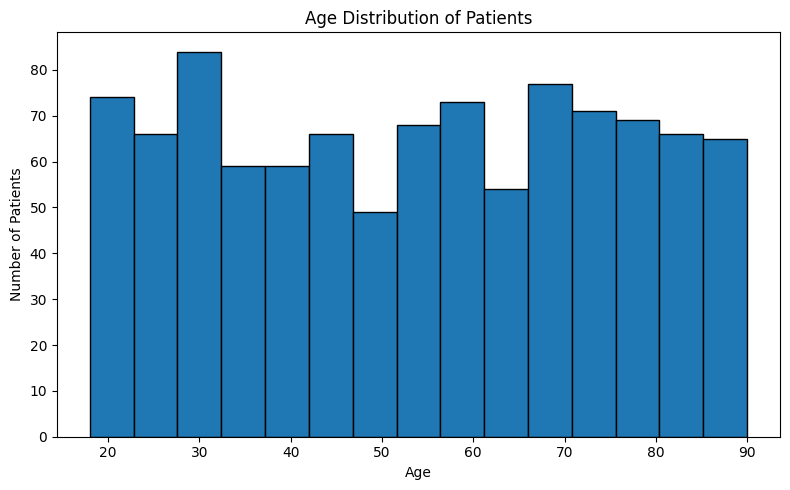

In [21]:
# Distribution of Age
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=15, edgecolor='black')
# Data label on the tallest bar only
counts, bins_edges = np.histogram(df['Age'], bins=15)
max_idx = counts.argmax()
bar_center = (bins_edges[max_idx] + bins_edges[max_idx+1]) / 2
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

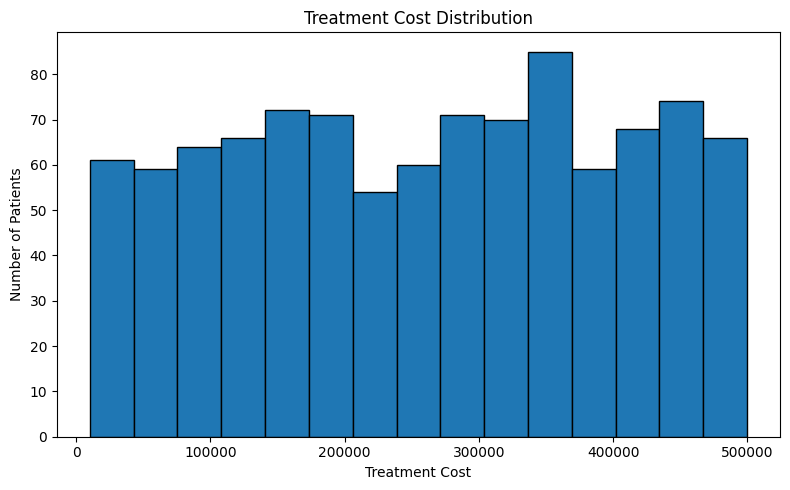

In [22]:
# Treatment Cost Distribution
plt.figure(figsize=(8, 5))
plt.hist(df['Treatment_Cost'], bins=15, edgecolor='black')
plt.title('Treatment Cost Distribution')
plt.xlabel('Treatment Cost')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

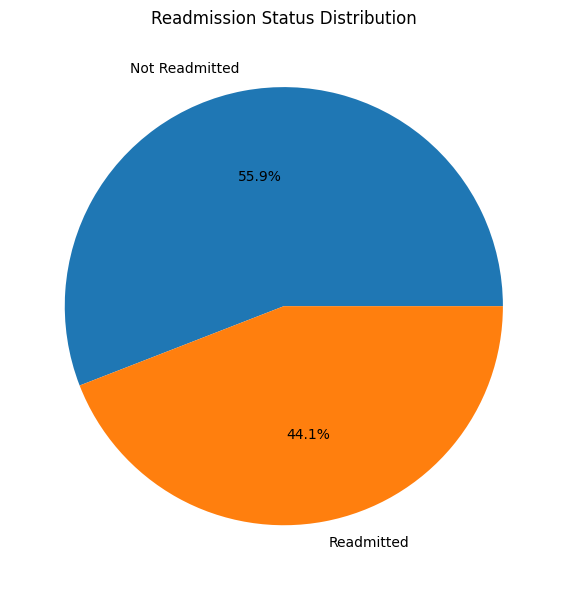

In [23]:
# Readmission Status - Pie Chart
readmit_counts = df['Readmission_Status'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(readmit_counts, labels=readmit_counts.index, autopct='%1.1f%%')
plt.title('Readmission Status Distribution')
plt.tight_layout()
plt.show()

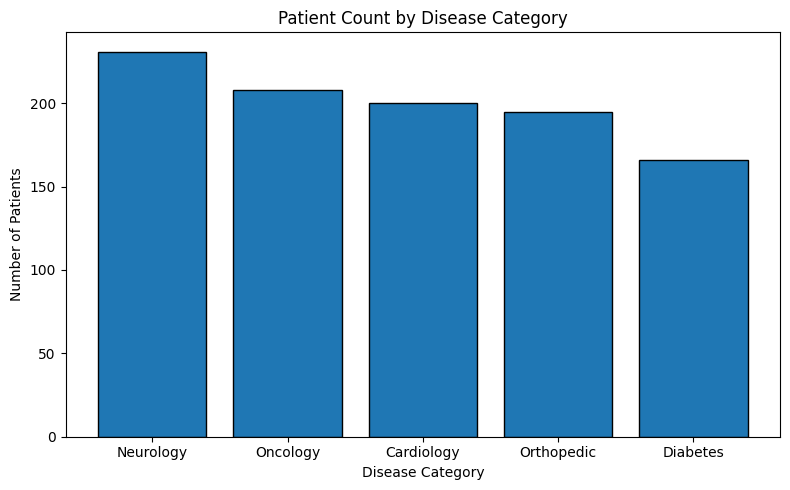

In [24]:
# Disease Category - Bar Chart
disease_counts = df['Disease_Category'].value_counts()
plt.figure(figsize=(8, 5))
bars = plt.bar(disease_counts.index, disease_counts.values, edgecolor='black')
plt.title('Patient Count by Disease Category')
plt.xlabel('Disease Category')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

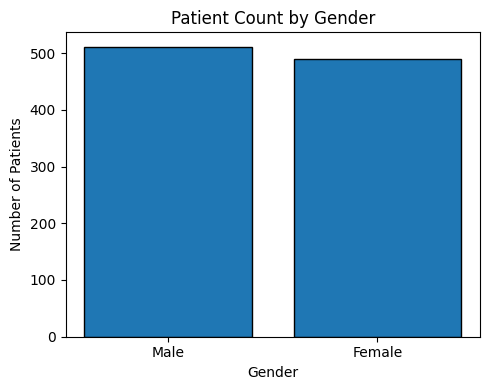

In [25]:
# Gender distribution
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(5, 4))
plt.bar(gender_counts.index, gender_counts.values, edgecolor='black')
plt.title('Patient Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

### 4.2 Bivariate Analysis

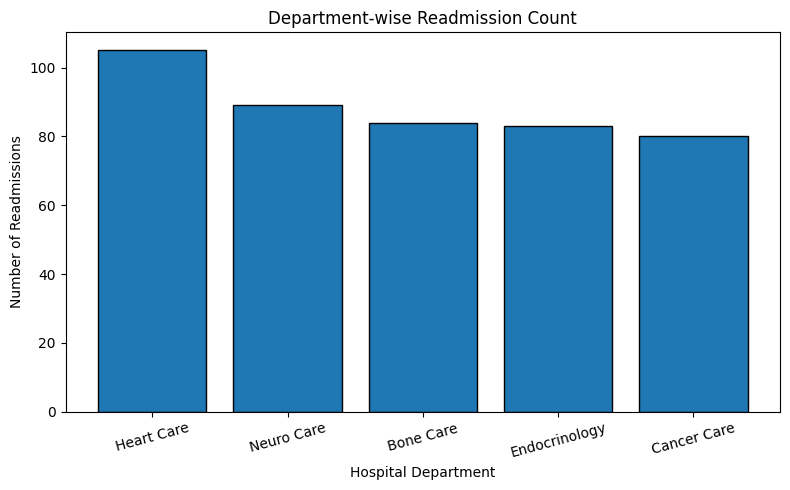

In [26]:
# Department-wise Readmission - Bar Chart
dept_readmit = df[df['Readmission_Status'] == 'Readmitted']['Hospital_Department'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(dept_readmit.index, dept_readmit.values, edgecolor='black')
plt.title('Department-wise Readmission Count')
plt.xlabel('Hospital Department')
plt.ylabel('Number of Readmissions')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

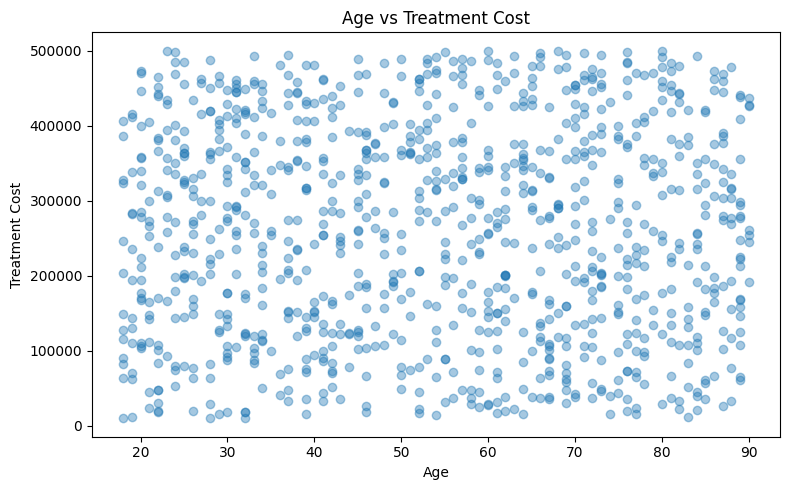

In [27]:
# Age vs Treatment Cost - Scatter Plot
plt.figure(figsize=(8, 5))
plt.scatter(df['Age'], df['Treatment_Cost'], alpha=0.4)
plt.title('Age vs Treatment Cost')
plt.xlabel('Age')
plt.ylabel('Treatment Cost')
plt.tight_layout()
plt.show()

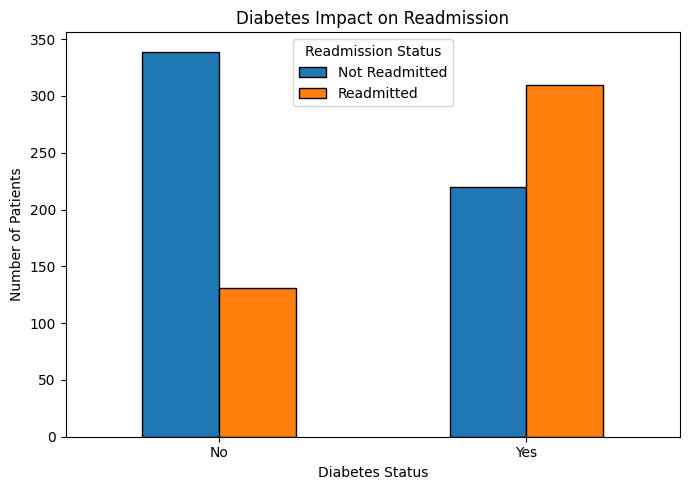

In [28]:
# Diabetes impact on readmission - Bar Chart
diabetes_readmit = df.groupby(['Diabetes', 'Readmission_Status']).size().unstack()
diabetes_readmit.plot(kind='bar', figsize=(7, 5), edgecolor='black')
plt.title('Diabetes Impact on Readmission')
plt.xlabel('Diabetes Status')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.legend(title='Readmission Status')
plt.tight_layout()
plt.show()

C:\Users\surya_t4rpfms\AppData\Local\Temp\ipykernel_7428\3291810194.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([readmitted, not_readmitted], labels=['Readmitted', 'Not Readmitted'])


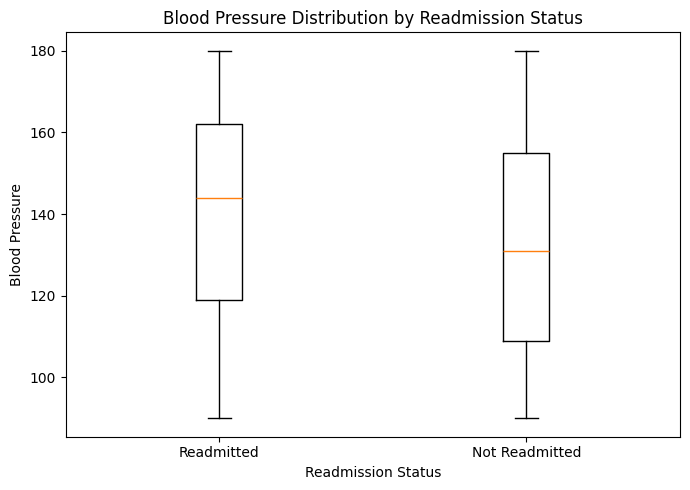

In [29]:
# Blood Pressure Box Plot by Readmission Status
plt.figure(figsize=(7, 5))
readmitted = df[df['Readmission_Status'] == 'Readmitted']['Blood_Pressure']
not_readmitted = df[df['Readmission_Status'] == 'Not Readmitted']['Blood_Pressure']
plt.boxplot([readmitted, not_readmitted], labels=['Readmitted', 'Not Readmitted'])
plt.title('Blood Pressure Distribution by Readmission Status')
plt.xlabel('Readmission Status')
plt.ylabel('Blood Pressure')
plt.tight_layout()
plt.show()

### 4.3 Correlation Analysis

In [30]:
df['Readmitted_Num'] = (df['Readmission_Status'] == 'Readmitted').astype(int)

corr_cols = ['Age', 'Days_Admitted', 'Treatment_Cost', 'Blood_Pressure', 'Readmitted_Num']
corr_matrix = df[corr_cols].corr().round(2)
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                 Age  Days_Admitted  Treatment_Cost  Blood_Pressure  \
Age             1.00           0.02           -0.00            0.04   
Days_Admitted   0.02           1.00            0.04           -0.03   
Treatment_Cost -0.00           0.04            1.00           -0.04   
Blood_Pressure  0.04          -0.03           -0.04            1.00   
Readmitted_Num  0.23           0.07           -0.01            0.15   

                Readmitted_Num  
Age                       0.23  
Days_Admitted             0.07  
Treatment_Cost           -0.01  
Blood_Pressure            0.15  
Readmitted_Num            1.00  


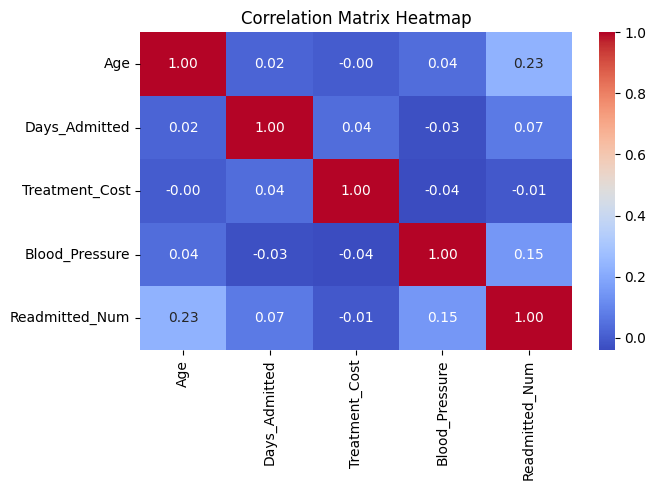

In [31]:
# Correlation Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

### 4.4 Distribution Analysis

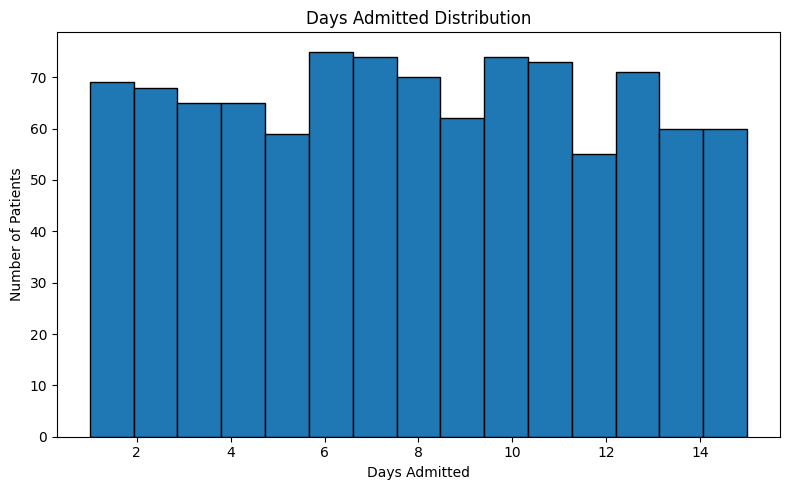

In [32]:
# Days Admitted Distribution
plt.figure(figsize=(8, 5))
plt.hist(df['Days_Admitted'], bins=15, edgecolor='black')
plt.title('Days Admitted Distribution')
plt.xlabel('Days Admitted')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

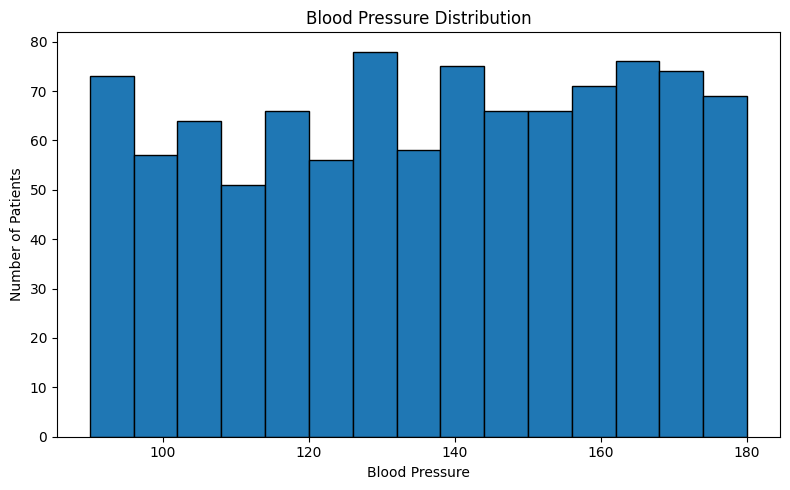

In [33]:
# Blood Pressure Distribution
plt.figure(figsize=(8, 5))
plt.hist(df['Blood_Pressure'], bins=15, edgecolor='black')
plt.title('Blood Pressure Distribution')
plt.xlabel('Blood Pressure')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

### 4.5 Trend Analysis

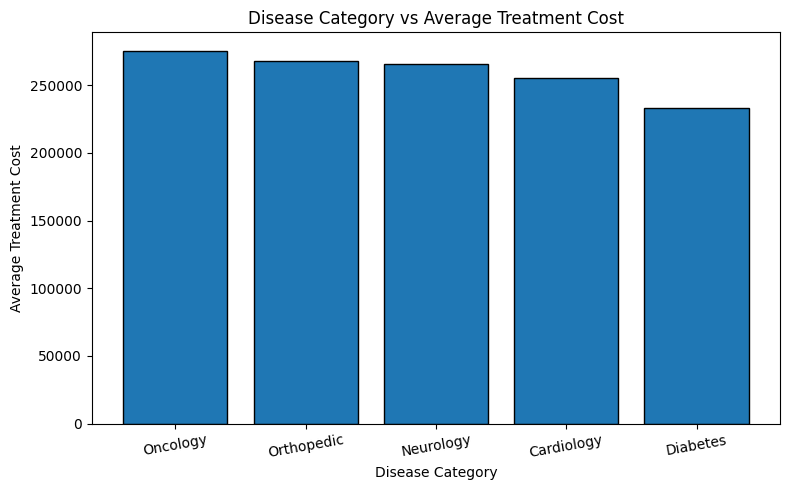

In [34]:
# Disease Category vs Average Treatment Cost - Bar Chart
avg_cost_disease = df.groupby('Disease_Category')['Treatment_Cost'].mean().sort_values(ascending=False).round(0)
plt.figure(figsize=(8, 5))
plt.bar(avg_cost_disease.index, avg_cost_disease.values, edgecolor='black')
plt.title('Disease Category vs Average Treatment Cost')
plt.xlabel('Disease Category')
plt.ylabel('Average Treatment Cost')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

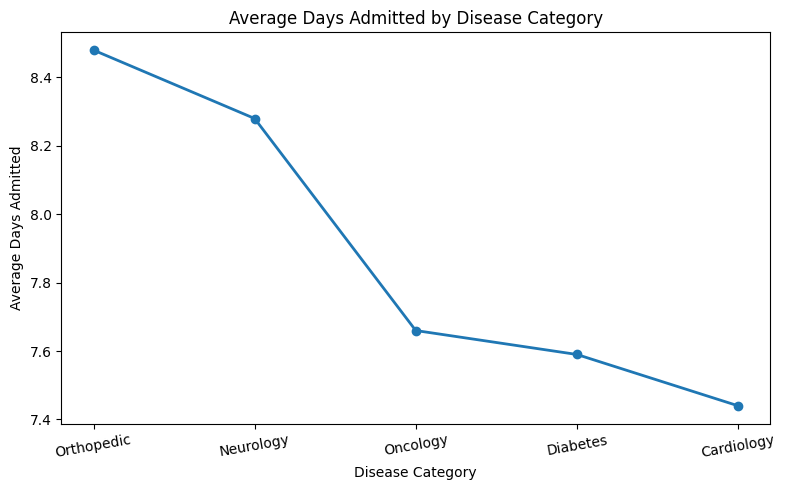

In [35]:
# Days admitted trend by disease
avg_days = df.groupby('Disease_Category')['Days_Admitted'].mean().sort_values(ascending=False).round(2)
plt.figure(figsize=(8, 5))
plt.plot(avg_days.index, avg_days.values, marker='o', linewidth=2)
plt.title('Average Days Admitted by Disease Category')
plt.xlabel('Disease Category')
plt.ylabel('Average Days Admitted')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

In [36]:
# Readmission rate by department
dept_readmit_rate = df.groupby('Hospital_Department')['Readmission_Status'].apply(
    lambda x: (x == 'Readmitted').mean() * 100
).sort_values(ascending=False).round(2)
print("Readmission rate by department (%):")
print(dept_readmit_rate)

Readmission rate by department (%):
Hospital_Department
Heart Care       52.50
Endocrinology    50.00
Bone Care        43.08
Neuro Care       38.53
Cancer Care      38.46
Name: Readmission_Status, dtype: float64
